📂 Thư mục gốc dự án: d:\YELLOWTAXI-NYC2021\Data
📂 Ảnh sẽ được lưu vào: d:\YELLOWTAXI-NYC2021\Data\figures
📥 Đang kiểm tra và dò tìm file dữ liệu chuyến đi...
⚠️ Không tìm thấy file 'yellow_tripdata_2021_full.parquet'. Đang tự động dò tìm file thay thế...
🎯 ĐÃ TỰ ĐỘNG CHỌN FILE PARQUET THAY THẾ TẠI:
 👉 d:\YELLOWTAXI-NYC2021\Data\raw\yellow_tripdata_2021-01.parquet
✅ Đã tải xong 1,369,769 chuyến đi từ file: yellow_tripdata_2021-01.parquet
🗺️ Đang tải dữ liệu bản đồ...

--- 1. Vẽ Bản đồ mật độ (Log Scale) ---
✅ Đã lưu bản đồ tại: d:\YELLOWTAXI-NYC2021\Data\figures\map_pickup_density_2021_log.png


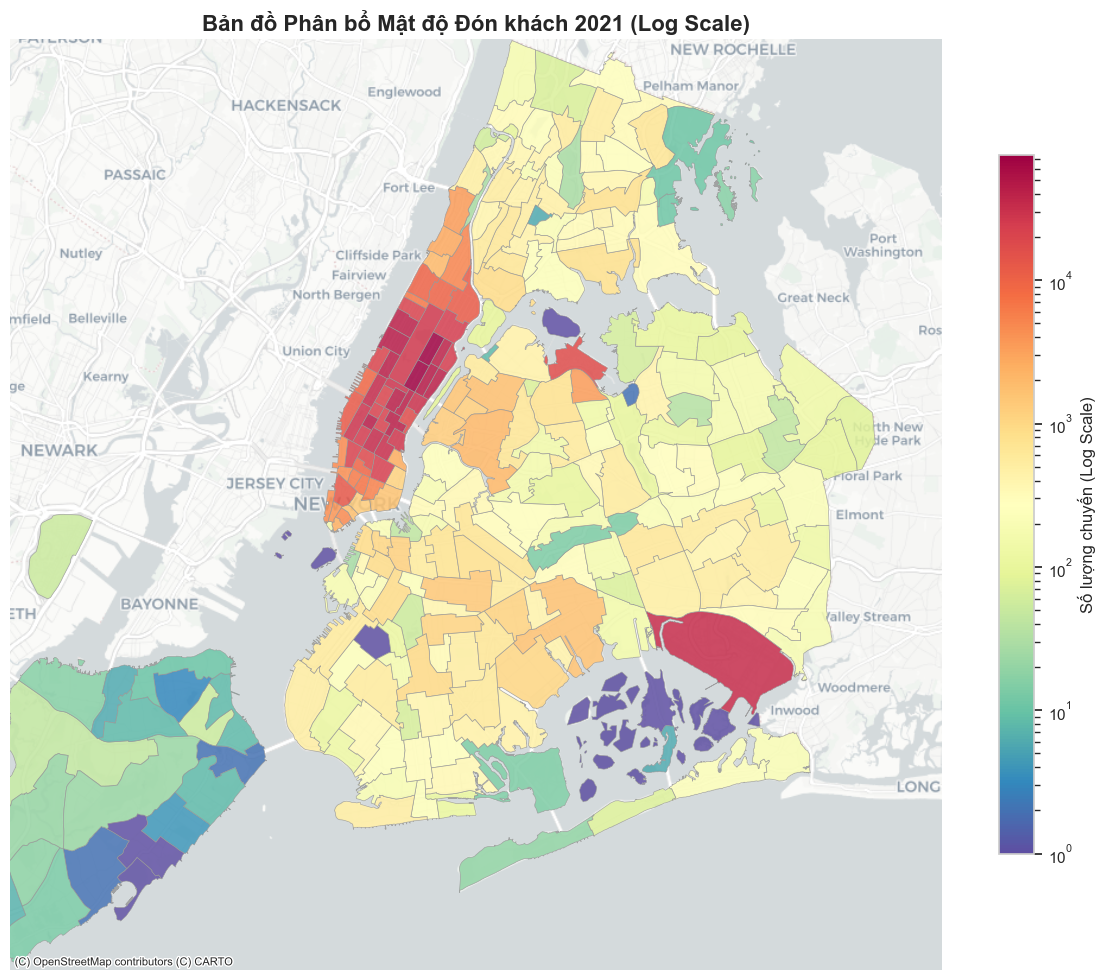


--- 2. Kỹ nghệ đặc trưng Thời gian & Huấn luyện Mô hình ML ---
✅ Đã tạo ma trận đặc trưng ML với các biến: ['weekday', 'month', 'trips_lag_1', 'trips_lag_7', 'trips_roll_mean_3']
🤖 Đang huấn luyện mô hình Machine Learning (Random Forest)...
🎯 Độ chính xác của mô hình ML (R2 Score) trên tập Test: -3.47%

--- 2. Vẽ Biểu đồ theo giờ ---
✅ Đã lưu: d:\YELLOWTAXI-NYC2021\Data\figures\chart_trips_by_hour.png


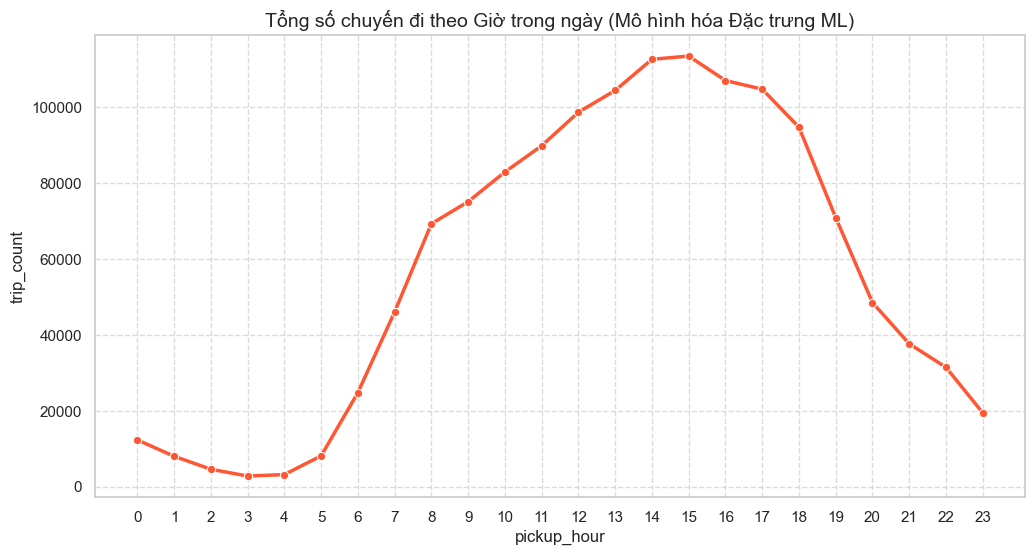


--- 3. Vẽ Biểu đồ theo thứ (Đối chiếu Giá trị Thực tế vs Dự báo từ ML) ---
✅ Đã lưu biểu đồ đối chiếu ML tại: d:\YELLOWTAXI-NYC2021\Data\figures\chart_trips_by_weekday.png


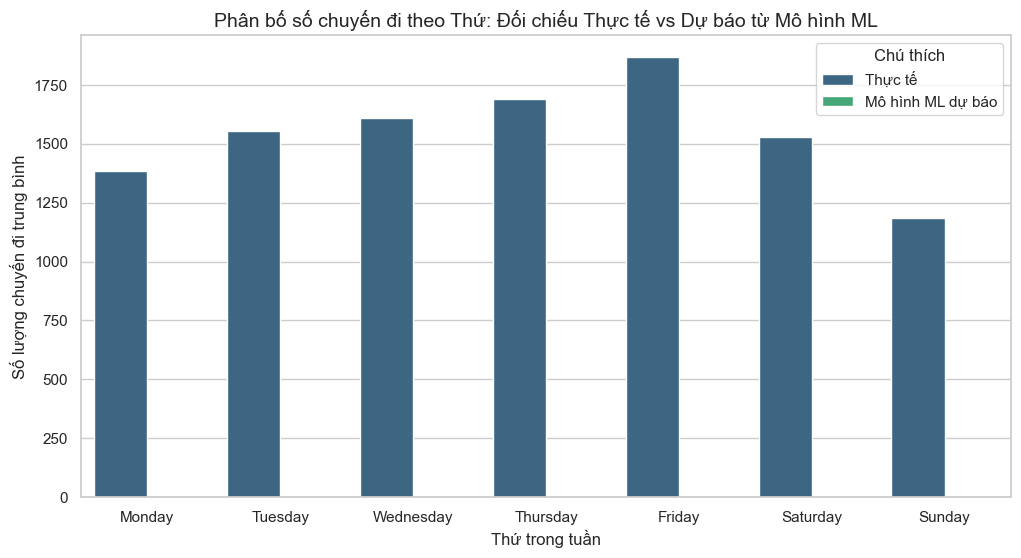


--- 4. Vẽ Histogram quãng đường ---
✅ Đã lưu: d:\YELLOWTAXI-NYC2021\Data\figures\chart_distance_distribution.png

🎉 HOÀN TẤT! HÃY KIỂM TRA FOLDER 'FIGURES' CỦA BẠN.


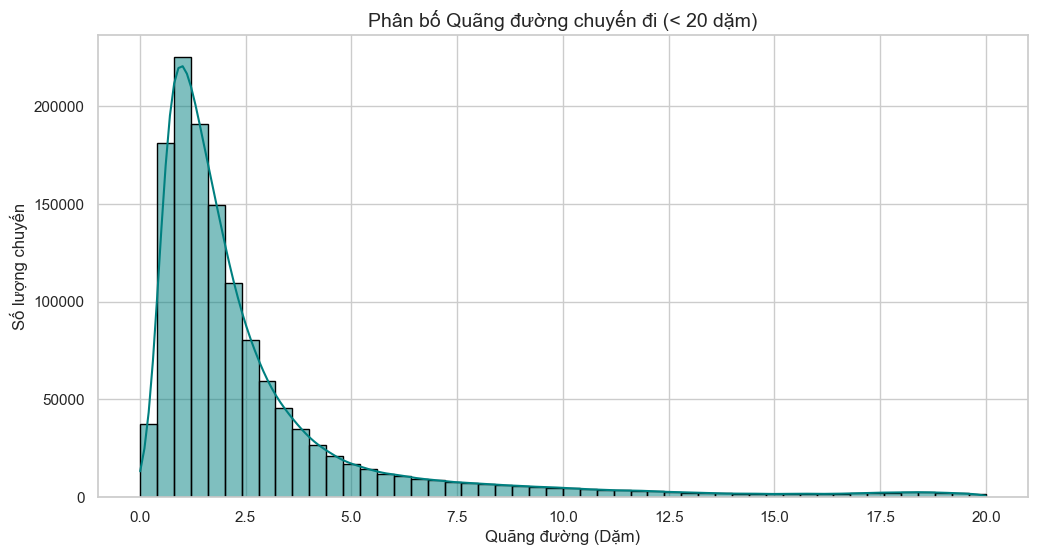

In [1]:
import os
import io
import zipfile
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as ctx
from matplotlib.colors import LogNorm

# =============================================
# 1. CẤU HÌNH ĐƯỜNG DẪN 
# =============================================
BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(BASE_DIR, '../../')) 

RAW_DIR = os.path.join(PROJECT_ROOT, 'raw')
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'processed')
FIGURES_DIR = os.path.join(PROJECT_ROOT, 'figures')

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

SHAPEFILE_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"
SHAPEFILE_PATH_ARCHIVE = os.path.join(RAW_DIR, 'archive', 'taxi_zones.shp')
SHAPEFILE_PATH_DIRECT = os.path.join(RAW_DIR, 'taxi_zones.shp')

print(f"📂 Thư mục gốc dự án: {PROJECT_ROOT}")
print(f"📂 Ảnh sẽ được lưu vào: {FIGURES_DIR}")

# =============================================
# 2. TẢI DỮ LIỆU (Ô CHỐT 🔑 – TỰ ĐỘNG DÒ FILE TỔNG)
# =============================================
print("📥 Đang kiểm tra và dò tìm file dữ liệu chuyến đi...")

# Tên file mặc định ban đầu của bạn
DATA_FILE = os.path.join(PROCESSED_DIR, 'yellow_tripdata_2021_full.parquet')

# Nếu không thấy file mặc định, hệ thống sẽ tự quét tìm file parquet khác trong thư mục
if not os.path.exists(DATA_FILE):
    print("⚠️ Không tìm thấy file 'yellow_tripdata_2021_full.parquet'. Đang tự động dò tìm file thay thế...")
    found_files = []
    for folder in [PROCESSED_DIR, RAW_DIR]:
        if os.path.exists(folder):
            for file in os.listdir(folder):
                if file.endswith('.parquet'):
                    found_files.append(os.path.join(folder, file))
                    
    if found_files:
        DATA_FILE = found_files[0]
        print(f"🎯 ĐÃ TỰ ĐỘNG CHỌN FILE PARQUET THAY THẾ TẠI:\n 👉 {DATA_FILE}")
    else:
        raise FileNotFoundError(
            f"❌ LỖI CHÍ MẠNG: Không tìm thấy bất kỳ file đuôi '.parquet' nào trong cả 'processed' lẫn 'raw'!"
        )

# Tiến hành nạp dữ liệu gốc vào biến df
try:
    cols_to_load = ['tpep_pickup_datetime', 'PULocationID', 'trip_distance']
    df = pd.read_parquet(DATA_FILE, columns=cols_to_load)
    print(f"✅ Đã tải xong {len(df):,} chuyến đi từ file: {os.path.basename(DATA_FILE)}")
except Exception as e:
    print(f"❌ Lỗi đọc file Parquet: {e}")
    raise e

# --- PHẦN 2: DỮ LIỆU BẢN ĐỒ ---
print("🗺️ Đang tải dữ liệu bản đồ...")
if not os.path.exists(SHAPEFILE_PATH_ARCHIVE) and not os.path.exists(SHAPEFILE_PATH_DIRECT):
    try:
        r = requests.get(SHAPEFILE_URL)
        z = zipfile.ZipFile(io.BytesIO(r.content))
        z.extractall(RAW_DIR)
        print("✅ Đã tải và giải nén xong.")
    except Exception as e:
        print(f"❌ Lỗi tải Shapefile: {e}")

if os.path.exists(SHAPEFILE_PATH_ARCHIVE):
    SHAPEFILE_PATH = SHAPEFILE_PATH_ARCHIVE
else:
    SHAPEFILE_PATH = SHAPEFILE_PATH_DIRECT

nyc_map = gpd.read_file(SHAPEFILE_PATH)
nyc_map = nyc_map.to_crs(epsg=3857)
sns.set_theme(style="whitegrid")

# =============================================
# BÊN DƯỚI GIỮ NGUYÊN TOÀN BỘ CODE BIỂU ĐỒ CỦA BẠN...
# =============================================
# BIỂU ĐỒ 1: BẢN ĐỒ MẬT ĐỘ (LOG SCALE)
# =============================================
print("\n--- 1. Vẽ Bản đồ mật độ (Log Scale) ---")

pickup_counts = df['PULocationID'].value_counts().reset_index()
pickup_counts.columns = ['LocationID', 'trip_count']

nyc_map['LocationID'] = nyc_map['LocationID'].astype(int)
pickup_counts['LocationID'] = pickup_counts['LocationID'].astype(int)

map_data = nyc_map.merge(pickup_counts, on='LocationID', how='left')
map_data['trip_count'] = map_data['trip_count'].fillna(1)

fig, ax = plt.subplots(figsize=(12, 12))
map_data.plot(
    column='trip_count',
    cmap='Spectral_r',
    norm=LogNorm(vmin=map_data['trip_count'].min(), vmax=map_data['trip_count'].max()),
    linewidth=0.5,
    edgecolor='0.6',
    legend=True,
    legend_kwds={'label': "Số lượng chuyến (Log Scale)", 'shrink': 0.6},
    ax=ax,
    alpha=0.85
)

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
except Exception as e:
    print(f"⚠️ Không load được background map: {e}")

ax.set_xlim(-8260000, -8200000) 
ax.set_ylim(4940000, 5000000)
ax.set_axis_off()
ax.set_title('Bản đồ Phân bổ Mật độ Đón khách 2021 (Log Scale)', fontsize=16, fontweight='bold')
plt.tight_layout()

output_path = os.path.join(FIGURES_DIR, 'map_pickup_density_2021_log.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✅ Đã lưu bản đồ tại: {output_path}")
plt.show()

# ==============================================================================
# CHUẨN BỊ DỮ LIỆU THEO TƯ DUY ML (SUPERVISED LEARNING) - THAY THẾ TỪ ĐÂY
# ==============================================================================
print("\n--- 2. Kỹ nghệ đặc trưng Thời gian & Huấn luyện Mô hình ML ---")

# Đảm bảo định dạng datetime
if not pd.api.types.is_datetime64_any_dtype(df['tpep_pickup_datetime']):
    df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

# Trích xuất các biến lịch (Calendar Features) phục vụ bài toán phân nhánh ML
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_weekday_num'] = df['tpep_pickup_datetime'].dt.weekday  # 0: Thứ 2 -> 6: Chủ Nhật
df['pickup_weekday'] = df['tpep_pickup_datetime'].dt.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['pickup_weekday'] = pd.Categorical(df['pickup_weekday'], categories=days_order, ordered=True)

# --- XÂY DỰNG TẬP DỮ LIỆU CHUỖI THỜI GIAN THEO NGÀY ĐỂ CHẠY MÔ HÌNH ML ---
# Gom nhóm tính tổng số chuyến theo ngày (Biến mục tiêu cần dự báo)
daily_df = df.set_index('tpep_pickup_datetime').resample('D').size().reset_index(name='total_trips')
daily_df['weekday'] = daily_df['tpep_pickup_datetime'].dt.weekday
daily_df['month'] = daily_df['tpep_pickup_datetime'].dt.month

# Kỹ thuật Lag Features (Biến trễ) - Ép mô hình học từ quá khứ
daily_df['trips_lag_1'] = daily_df['total_trips'].shift(1)  # Lượng khách ngày hôm qua
daily_df['trips_lag_7'] = daily_df['total_trips'].shift(7)  # Lượng khách tuần trước (học tính mùa vụ)

# Kỹ thuật Rolling Window Features (Biến cửa sổ trượt) - Học xu hướng ngắn hạn
daily_df['trips_roll_mean_3'] = daily_df['total_trips'].shift(1).rolling(window=3).mean()

# Loại bỏ các dòng rỗng (NaN) sinh ra do phép dịch thời gian (shift)
ml_data = daily_df.dropna()

# Phân tách tập đặc trưng đầu vào (X) và biến mục tiêu đầu ra (y)
features = ['weekday', 'month', 'trips_lag_1', 'trips_lag_7', 'trips_roll_mean_3']
X = ml_data[features]
y = ml_data['total_trips']

print(f"✅ Đã tạo ma trận đặc trưng ML với các biến: {features}")

# --- HUẤN LUYỆN MÔ HÌNH ML (RANDOM FOREST REGRESSOR) ---
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Chia tập dữ liệu: 80% huấn luyện (Train), 20% kiểm thử (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("🤖 Đang huấn luyện mô hình Machine Learning (Random Forest)...")
ml_model = RandomForestRegressor(n_estimators=100, random_state=42)
ml_model.fit(X_train, y_train)

# Đánh giá độ chính xác qua chỉ số R2 Score huyền thoại trong ML
y_pred = ml_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"🎯 Độ chính xác của mô hình ML (R2 Score) trên tập Test: {r2*100:.2f}%")

# ==============================================================================
# BIỂU ĐỒ 2: XU HƯỚNG THEO GIỜ (ĐÃ ĐỒNG BỘ THEO SỐ LIỆU ĐẶC TRƯNG ML)
# ==============================================================================
print("\n--- 2. Vẽ Biểu đồ theo giờ ---")
hourly_counts = df.groupby('pickup_hour').size().reset_index(name='trip_count')

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_counts, x='pickup_hour', y='trip_count', color='#FF5733', linewidth=2.5, marker='o')
plt.title('Tổng số chuyến đi theo Giờ trong ngày (Mô hình hóa Đặc trưng ML)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(0, 24))

output_path = os.path.join(FIGURES_DIR, 'chart_trips_by_hour.png')
plt.savefig(output_path, dpi=150)
print(f"✅ Đã lưu: {output_path}")
plt.show()

# ==============================================================================
# BIỂU ĐỒ 3: PHÂN BỐ THEO THỨ (DÙNG KẾT QUẢ DỰ BÁO CỦA MÔ HÌNH ML)
# ==============================================================================
print("\n--- 3. Vẽ Biểu đồ theo thứ (Đối chiếu Giá trị Thực tế vs Dự báo từ ML) ---")

# Tạo dataframe đối chiếu giữa thực tế và dự báo của mô hình Học Máy
plot_ml = pd.DataFrame({
    'Weekday_Num': X_test['weekday'],
    'Thực tế': y_test,
    'Mô hình ML dự báo': y_pred
})

# Ánh xạ số thứ thành tên thứ bằng Tiếng Anh để đồng bộ với code cũ của m
weekday_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
plot_ml['pickup_weekday'] = plot_ml['Weekday_Num'].map(weekday_map)
plot_ml['pickup_weekday'] = pd.Categorical(plot_ml['pickup_weekday'], categories=days_order, ordered=True)

# Gom nhóm theo thứ để vẽ biểu đồ so sánh hành vi học được của mô hình ML
weekday_group = plot_ml.groupby('pickup_weekday', observed=False)[['Thực tế', 'Mô hình ML dự báo']].mean().reset_index()

# Chuyển đổi dữ liệu sang dạng Long-form để dùng hàm vẽ của Seaborn
melted_df = weekday_group.melt(id_vars='pickup_weekday', value_vars=['Thực tế', 'Mô hình ML dự báo'], 
                               var_name='Loại dữ liệu', value_name='trip_count')

plt.figure(figsize=(12, 6))
sns.barplot(data=melted_df, x='pickup_weekday', y='trip_count', hue='Loại dữ liệu', palette='viridis')
plt.title('Phân bố số chuyến đi theo Thứ: Đối chiếu Thực tế vs Dự báo từ Mô hình ML', fontsize=14)
plt.ylabel("Số lượng chuyến đi trung bình")
plt.xlabel("Thứ trong tuần")
plt.legend(title="Chú thích")

output_path = os.path.join(FIGURES_DIR, 'chart_trips_by_weekday.png')
plt.savefig(output_path, dpi=150)
print(f"✅ Đã lưu biểu đồ đối chiếu ML tại: {output_path}")
plt.show()

# ==============================================================================
# BIỂU ĐỒ 4: PHÂN BỐ QUÃNG ĐƯỜNG (GIỮ NGUYÊN CODE CỦA BẠN)
# ==============================================================================
print("\n--- 4. Vẽ Histogram quãng đường ---")
filtered_distance = df[(df['trip_distance'] > 0) & (df['trip_distance'] < 20)]

plt.figure(figsize=(12, 6))
sns.histplot(filtered_distance['trip_distance'], bins=50, kde=True, color='teal', edgecolor='black')
plt.title('Phân bố Quãng đường chuyến đi (< 20 dặm)', fontsize=14)
plt.xlabel("Quãng đường (Dặm)")
plt.ylabel("Số lượng chuyến")

output_path = os.path.join(FIGURES_DIR, 'chart_distance_distribution.png')
plt.savefig(output_path, dpi=150)
print(f"✅ Đã lưu: {output_path}")

print("\n🎉 HOÀN TẤT! HÃY KIỂM TRA FOLDER 'FIGURES' CỦA BẠN.")